# Field inference of a single (realistic) source with the Fast Multipole Method

This notebook calcuates the potential of a single source via the Fast Multipole Method in 2D (https://github.com/flatironinstitute/fmm2d) and serves as a benchmark for our novel method.

In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure
from hypermagnetics.fmm_sources import potential2D, field2d_grid
from hypermagnetics.mt_eval import field_mt, field_exact


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

## I. Target definition and data generation

The dipole field at $\mathbf{r}$ from a collection of point-like sources with moments $\mathbf{m}_i$ and positions $\mathbf{r}_i$ is computed via the scalar potential as $${\mu_0}\mathbf{H}_{\odot}(\mathbf{r}) = -\nabla\sum_{i=1}^N \underbrace{\overbrace{\frac{1}{2\pi |\mathbf{r}-\mathbf{r_i}|}}^{\text{Surface of 2D ball}}\overbrace{\frac{\mathbf{m}_i\cdot(\mathbf{r}-\mathbf{r_i})}{|\mathbf{r}-\mathbf{r_i}|}}^{\text{dipole term}}}_{\text{scalar potential }\psi_i}.$$

We generate random samples to serve as the training data, precomputing the target potential values. First, we describe the collection of sources.

CUDA backend failed to initialize: INTERNAL: no supported devices found for platform CUDA.(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


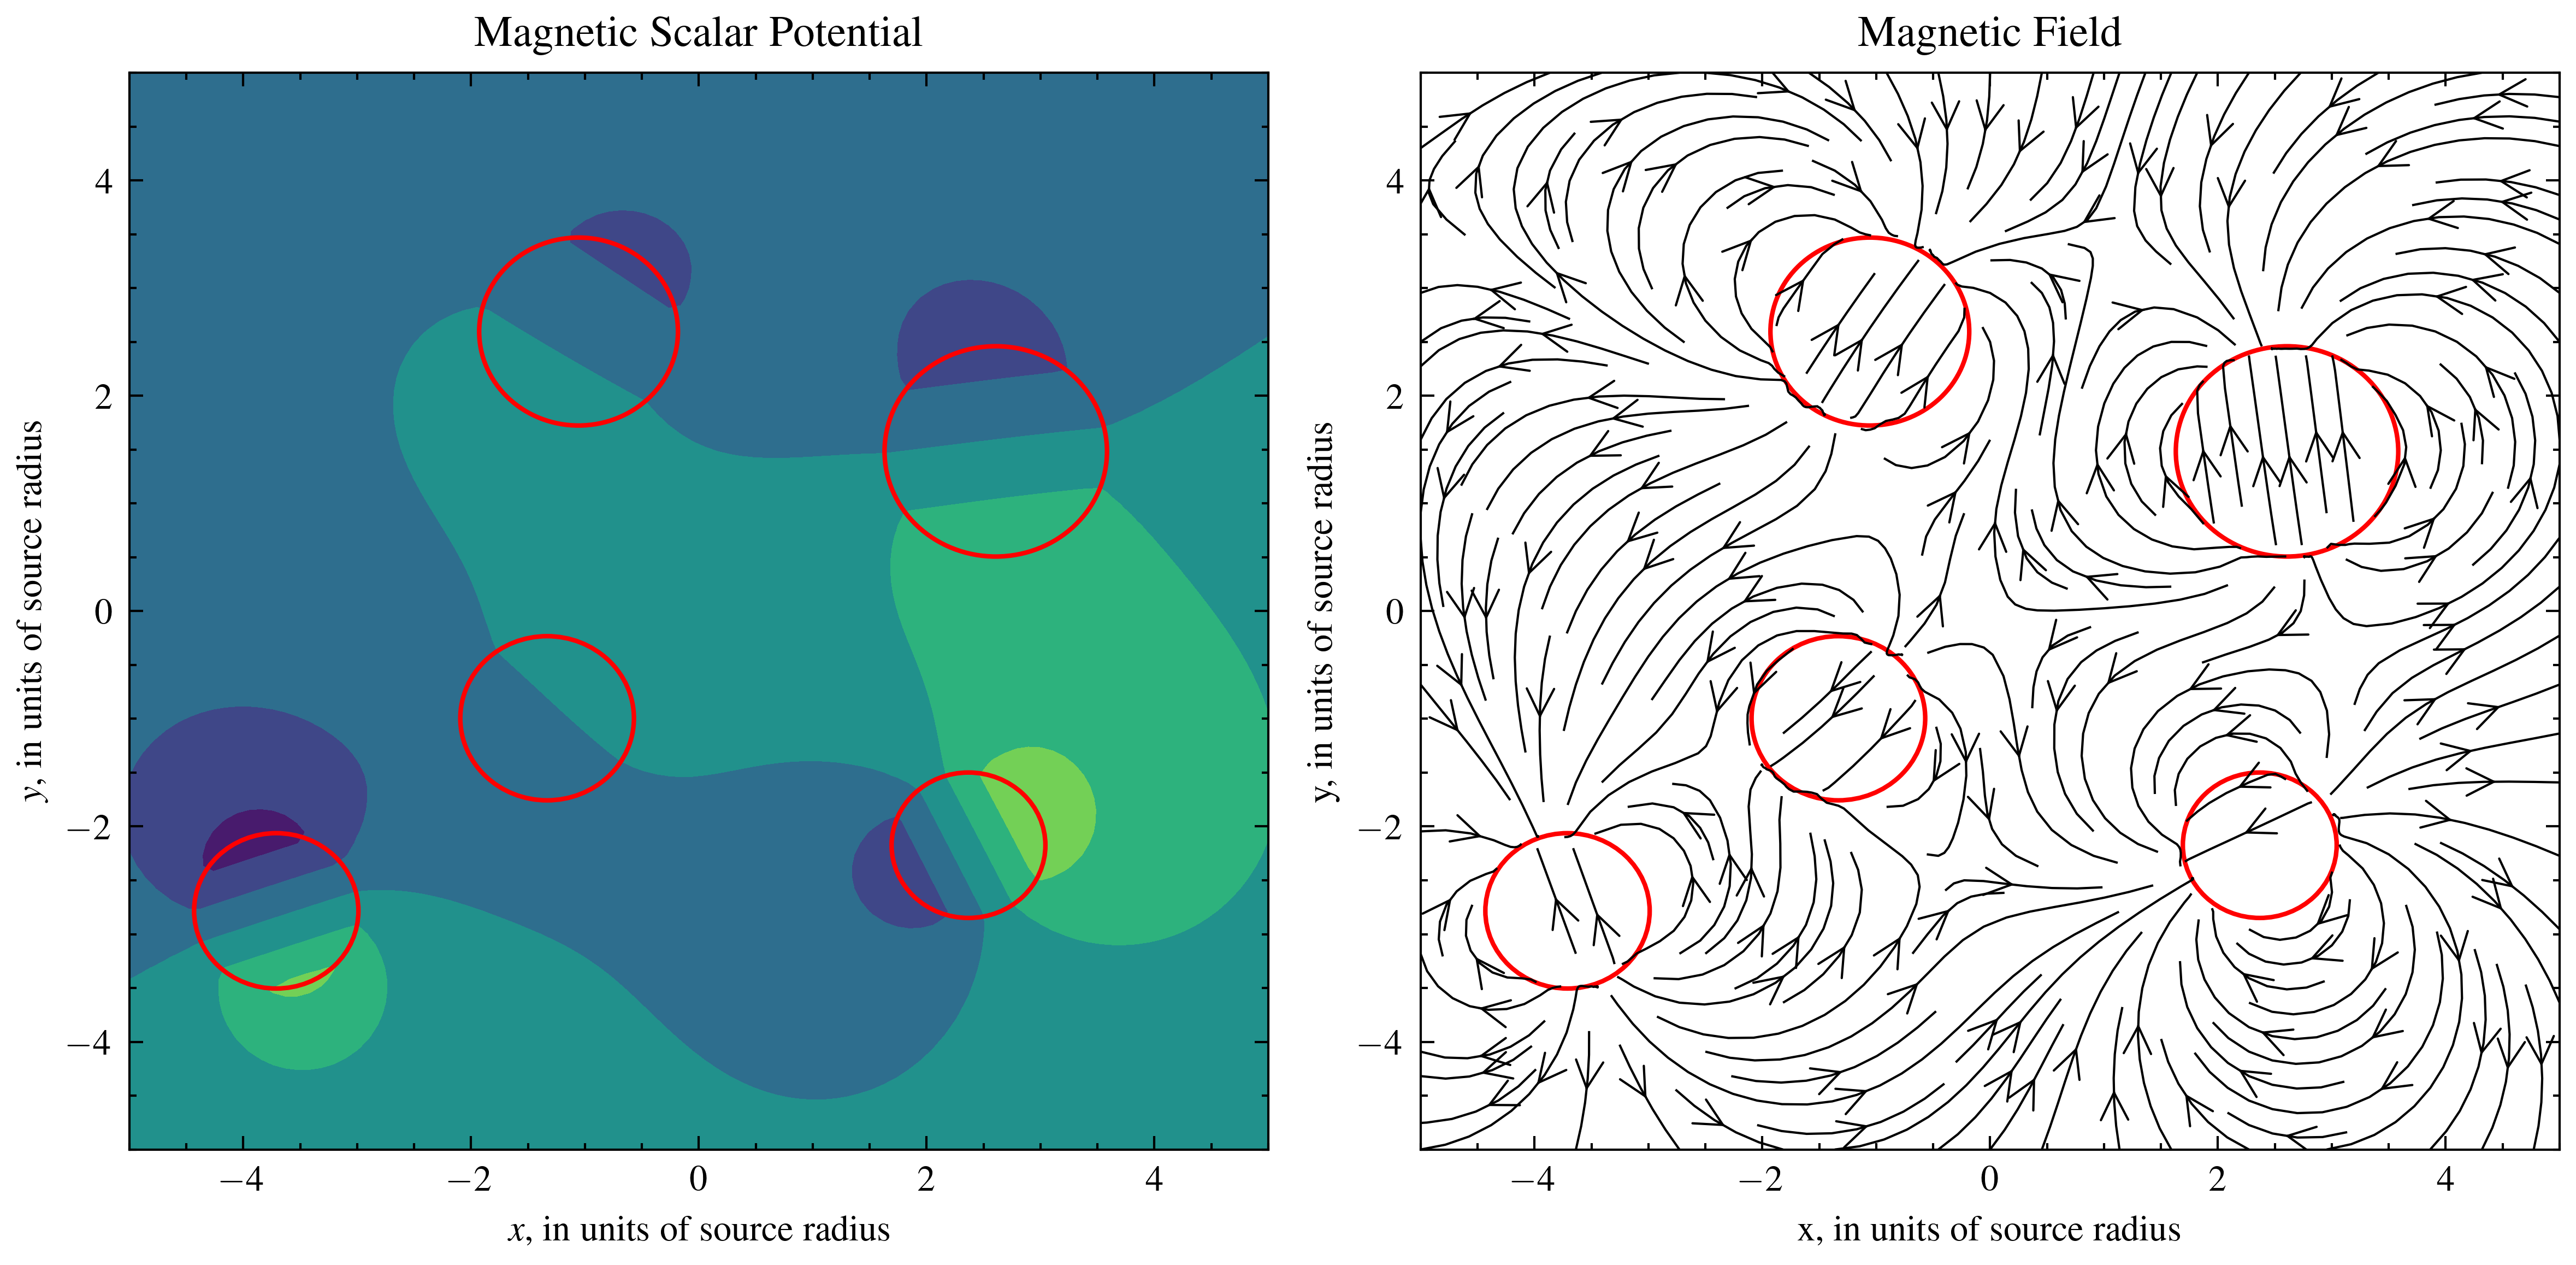

In [2]:
source_cfg = {
    "shape": "sphere",
    "n_samples": 1,
    "n_sources": 5,
    "lim": 5,
    "res": 96,
    "dim": 2,
    "min_size": 0.5,
    "max_size": 1,
    "t_source": True,
    "line": False,
    "eps": 0,
    "seed": 2,
}
train = configure(**source_cfg)
plots(train, loc=False, edge=True)

## Code from FMM2D
https://github.com/flatironinstitute/fmm2d/blob/main/src/laplace/rfmm2d.f#L144
- 2D dipole vector is represented in complex form `dx + i*dy`
- Can then be more easily treated as directional derivatives of monopole (source) potentials
- negative sign in `ztmp` is conventional; **TODO** Check how FMM is using this in Green's function

```
do i = 1,ns
    do j = 1,nd
        ztmp = -(dipvec(j,1,i)+eye*dipvec(j,2,i))
        dipstr1(j,i) = dipstr(j,i)*ztmp
    enddo
enddo
```


Potential: 9.056332e-09


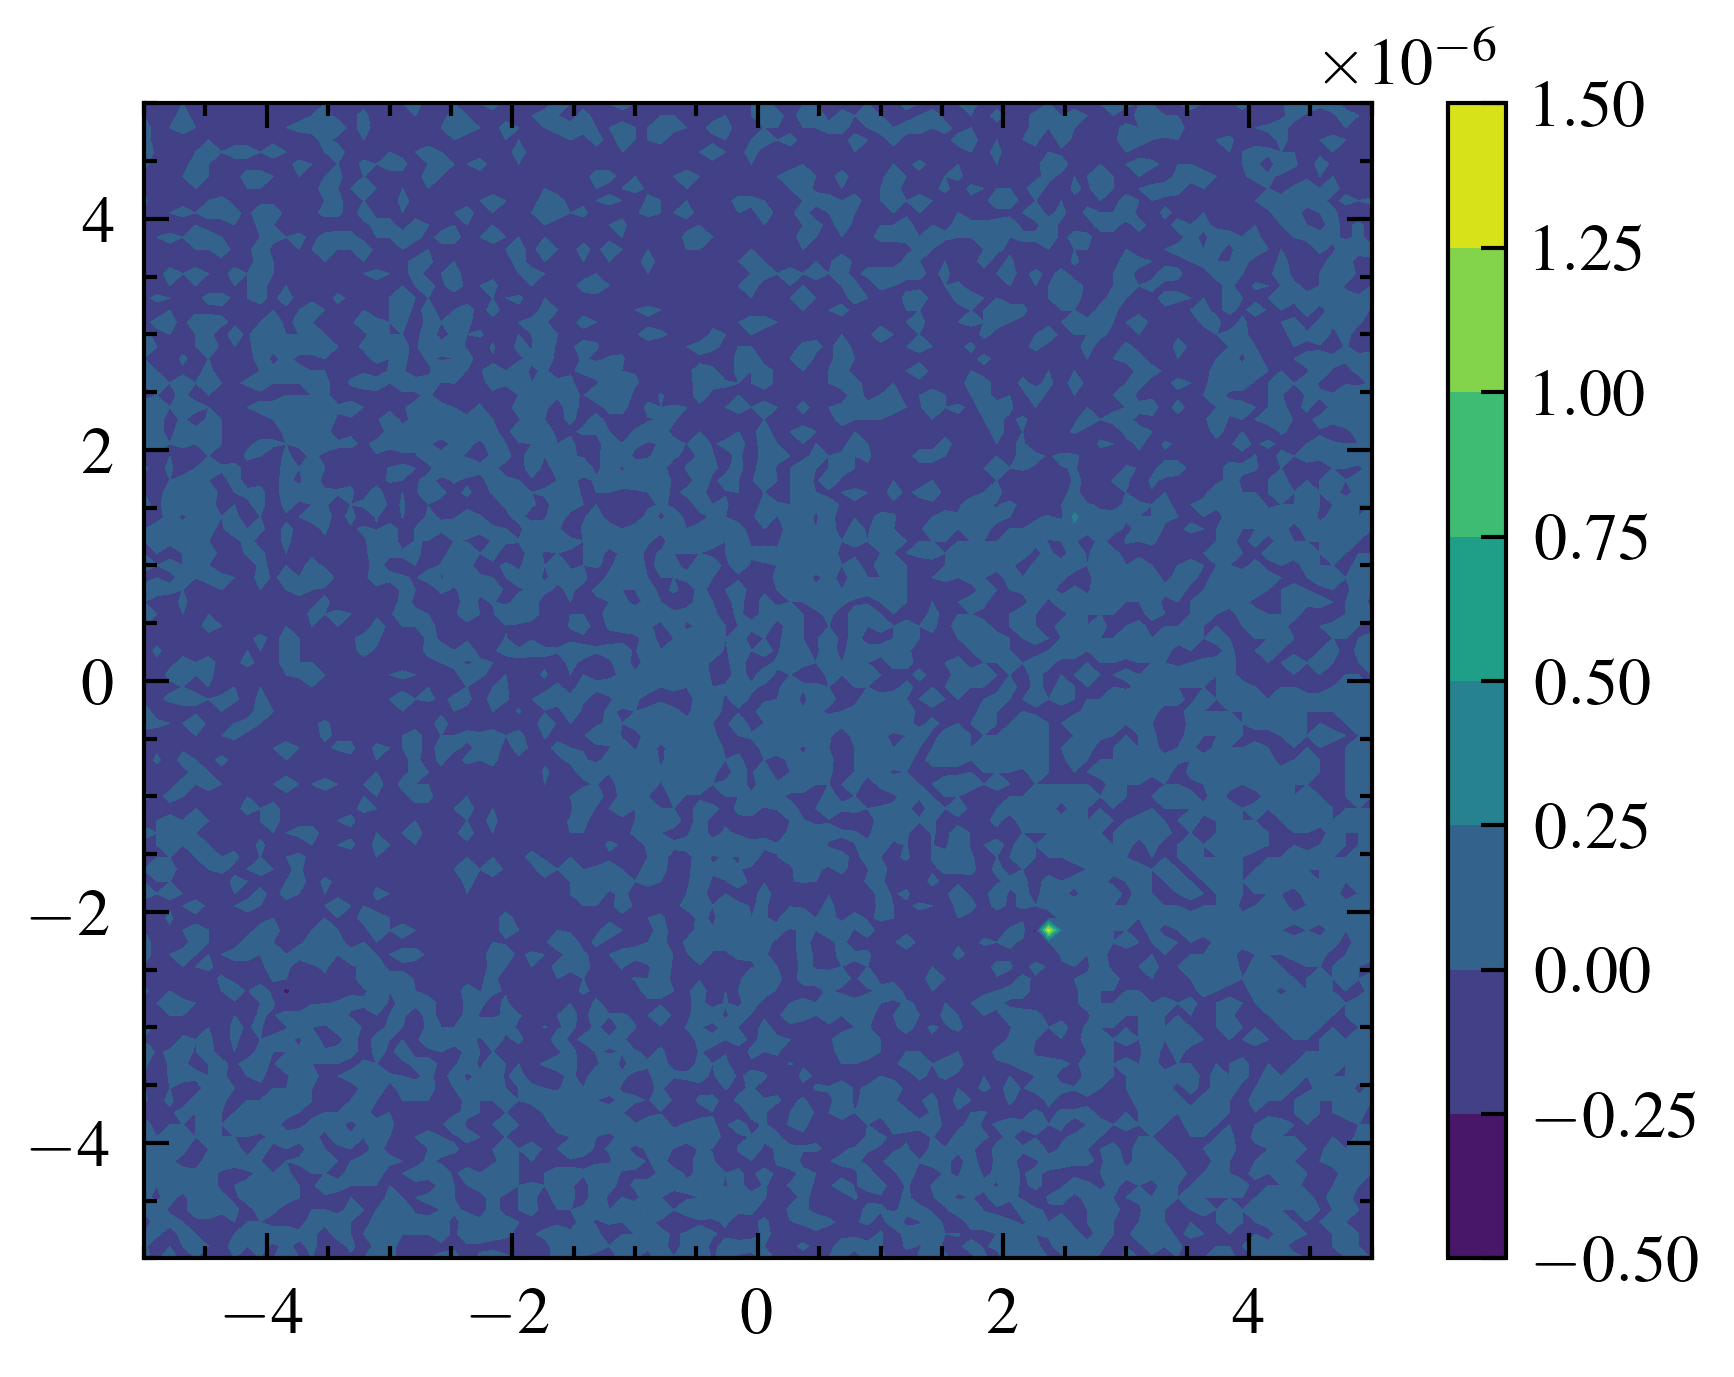

In [3]:
sim = train.copy()
sim['msp_grid'], _ = potential2D(sim['sources'], sim['grid'], sim['shape'])

### Potential
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["msp_grid"][0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["msp_grid"][0]), color='red', linestyle='--')
    plt.yscale("log")
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_msp = sim["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    t_msp = train["msp_grid"][0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, sim_msp)
    plt.contourf(x_grid, y_grid, np.clip(sim_msp - t_msp, -0.5, 0.5))
    plt.colorbar()

print("Potential:", np.nanmean(np.abs(sim_msp - t_msp)))

Field(x): 1.2240918


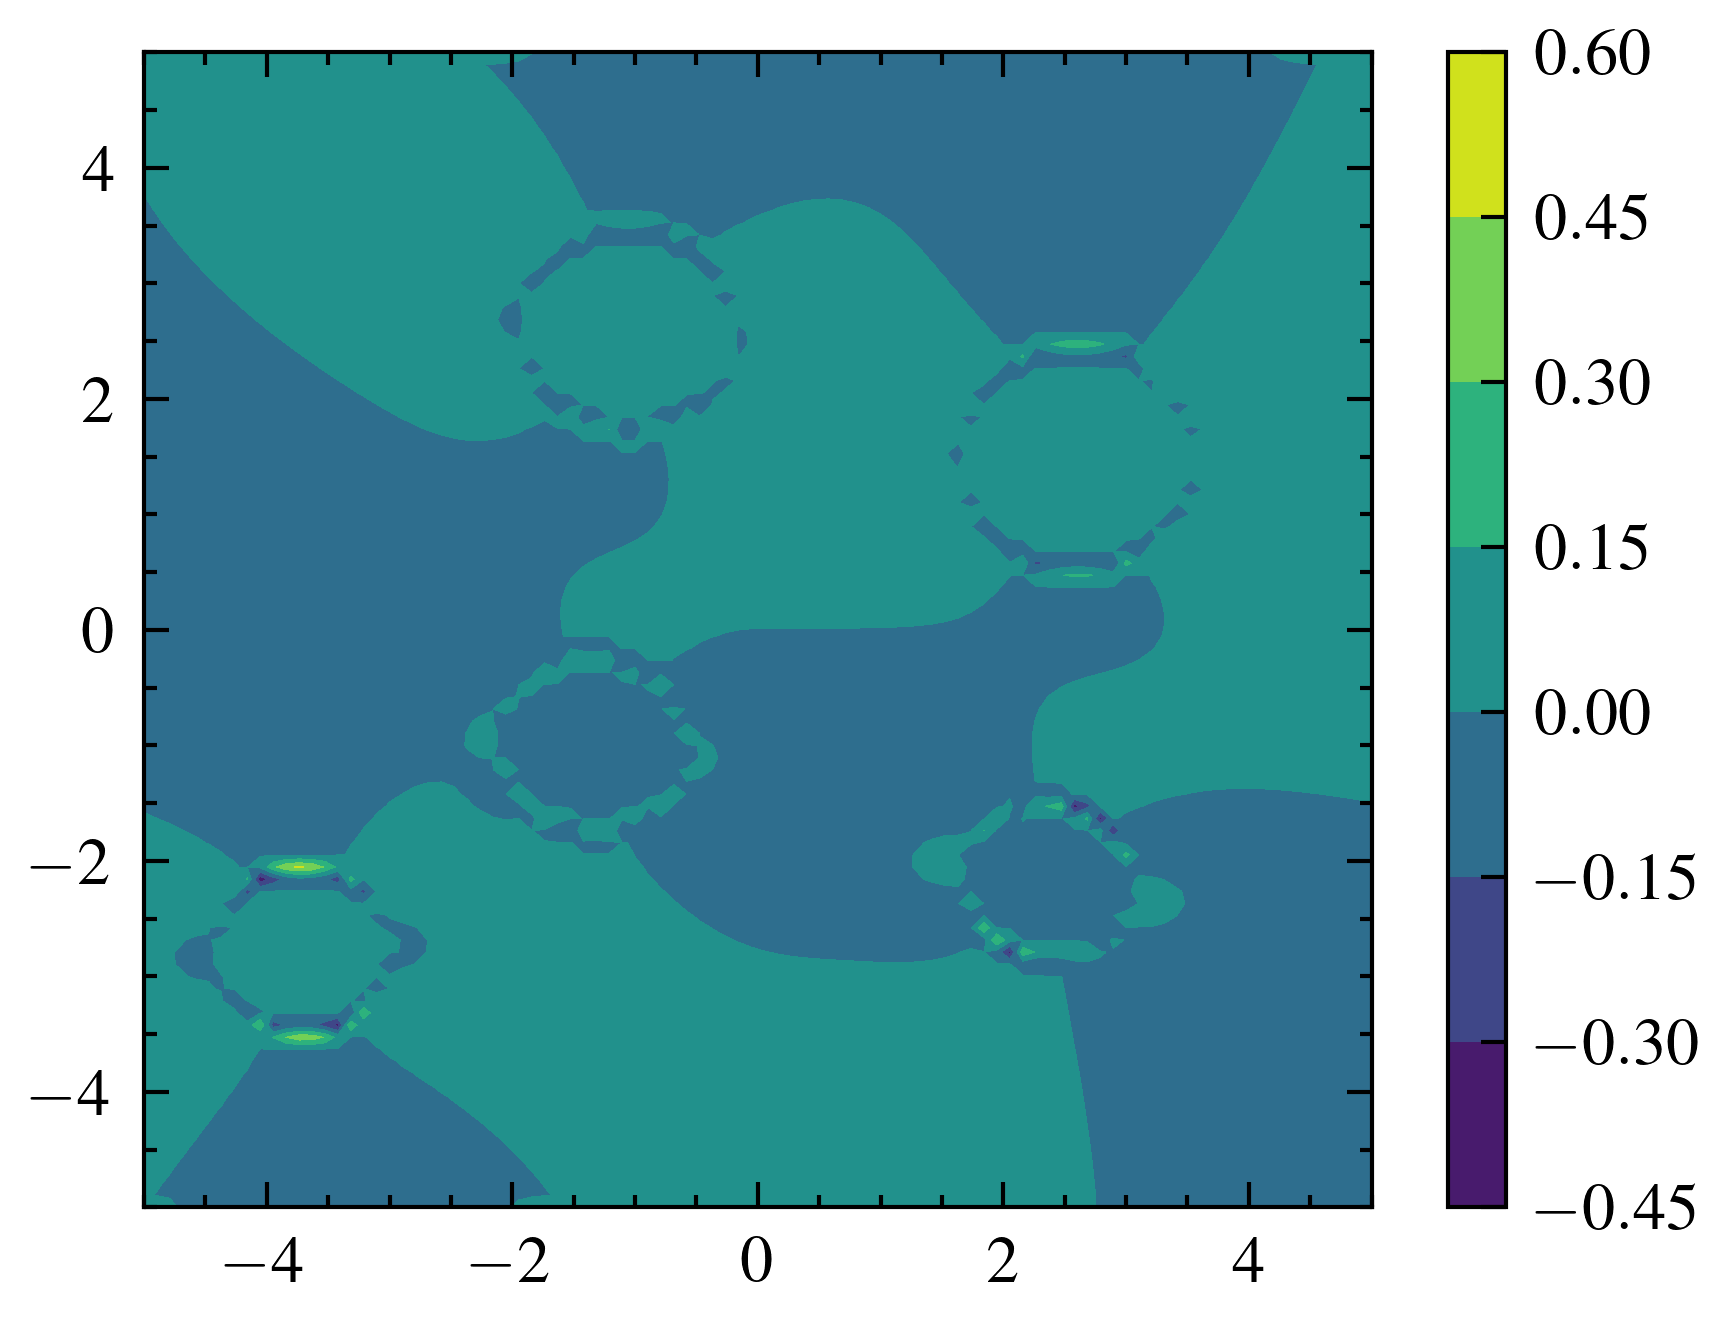

In [ ]:
sim["field_grid"] = field2d_grid(source_cfg, sim["msp_grid"])

### Field in x-direction
if source_cfg["line"]:
    plt.plot(sim['grid'][:, 0], np.abs(sim["field_grid"][0, ..., 0]))
    plt.plot(sim['grid'][:, 0], np.abs(train["field_grid"][0, ..., 0]), color='red', linestyle='--')
    plt.yscale("log")
else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    sim_f = sim["field_grid"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    t_f = train["field_grid"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f, -5, 5))
    # plt.contourf(x_grid, y_grid, np.clip(t_f, -1, 1))
    plt.contourf(x_grid, y_grid, np.clip(sim_f - t_f, -0.5, 0.5))
    # plt.contourf(x_grid, y_grid, np.clip(sim_f / t_f, 0, 3))
    plt.colorbar()

    print("Field(x):", np.nanmean(np.abs(sim_f / t_f)))

A realistic (non-pointlike) source will have, in two dimensions, the form $\mathbf{H}(\mathbf{r}) = - \mathbb{N}(\mathbf{r})\mathbf{M}$ inside the source, and by Gauss' Law $\mathbf{H} \sim \mathbf{H}_\odot$ outside it. The distinguishing feature of the dipole term is the $\sim 1/r$ dependence; higher multipole terms ($1/r^2$, $1/r^3$) might also be included, but the dipole term will quickly dominate at larger $r$.

In our simulation, we assume to have a ball of uniform magnetization. To achieve a solution via the FMM framework, we simply calculate the solutions of multiple pure (point-like) dipoles and we then set the inside of the magnet to the known constant value of $\frac{(r-r') \cdot \mathbf{m}}{2\pi R^2}$.

*Note: Magnets cannot overlap in this scenario.*

## Equivalent for MagTense

Field(x): 1.005891


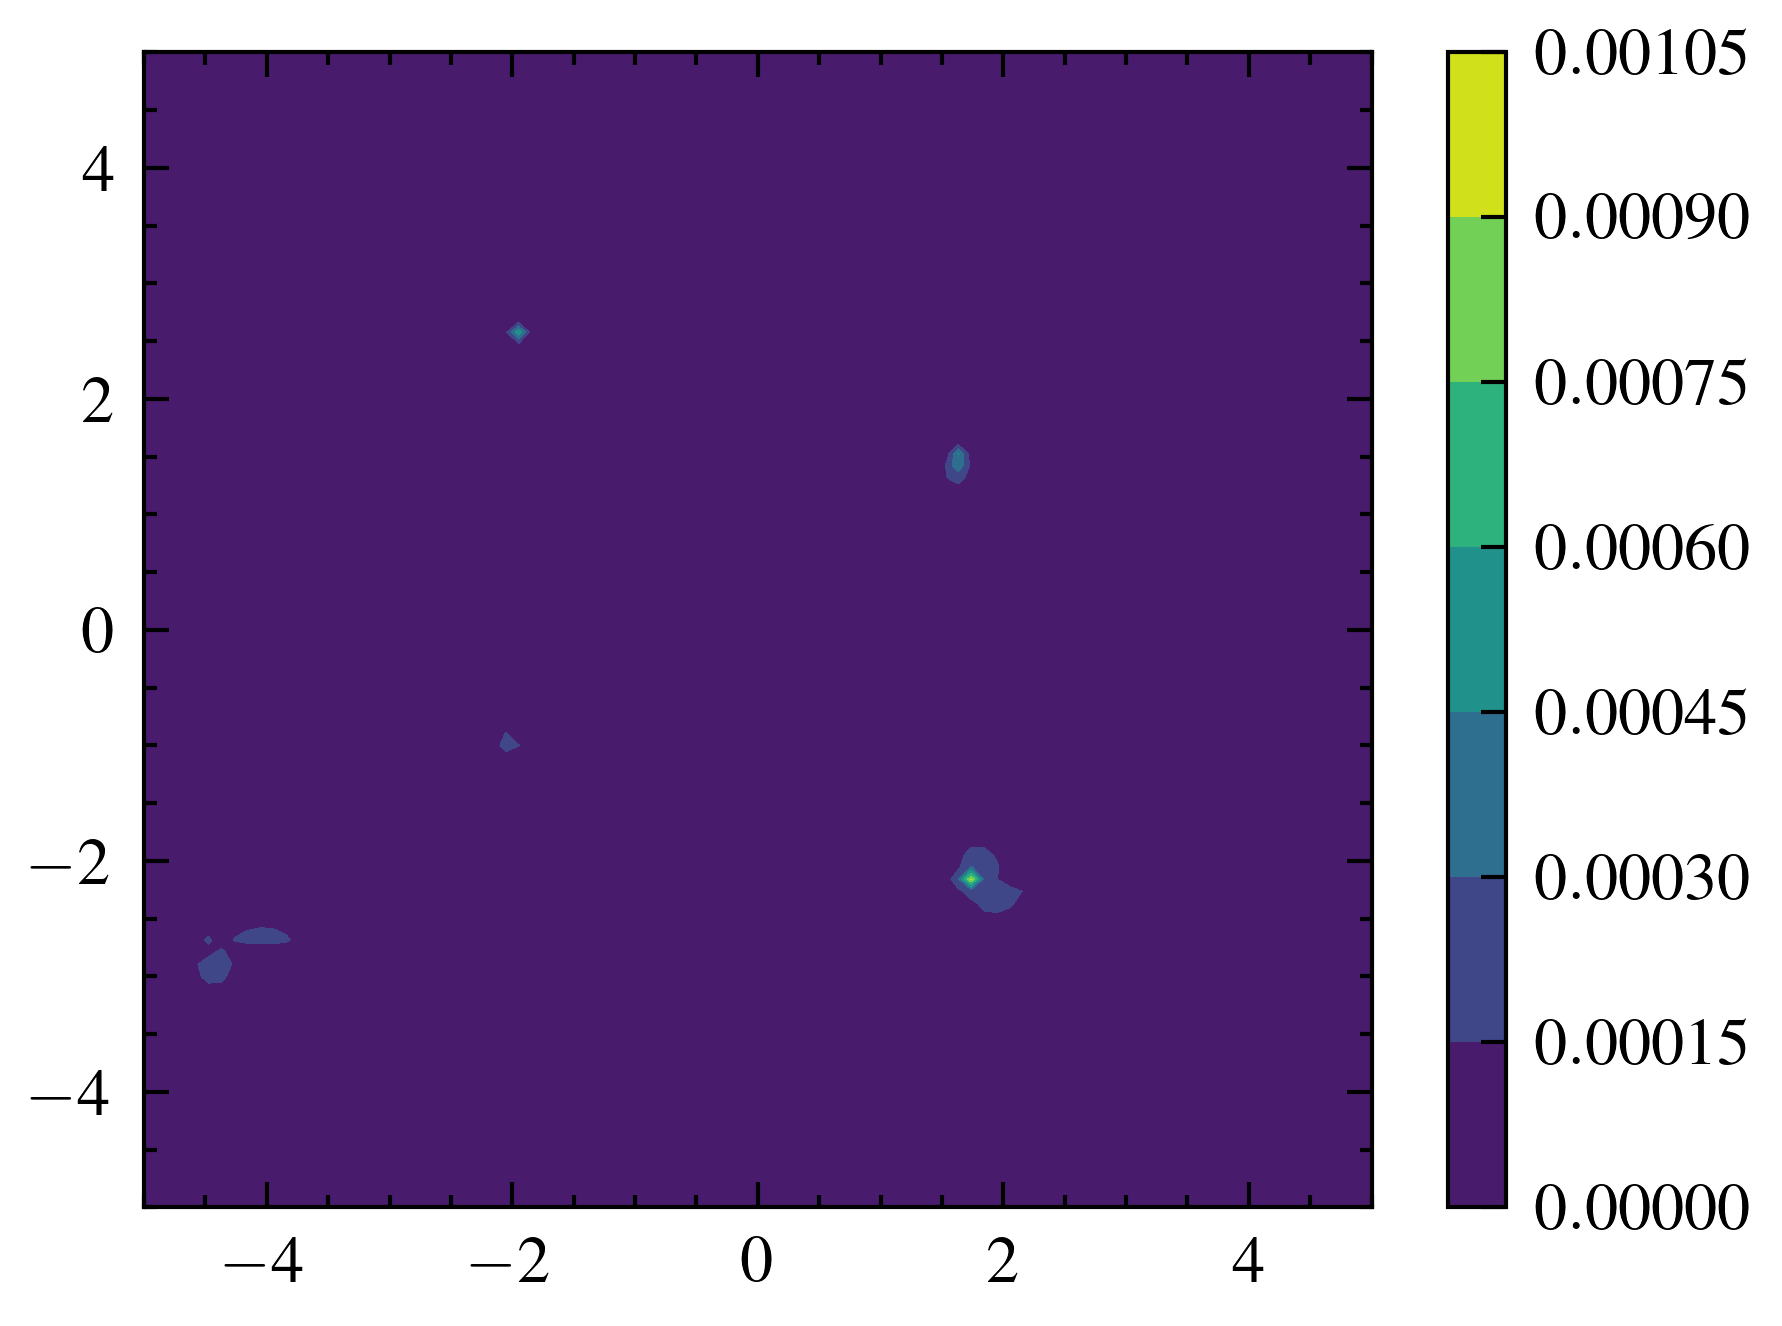

In [14]:
mt_sim, _ = field_mt(train['sources'], train['grid'], train['shape'], length=100)

if source_cfg["line"]:
    plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0])
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    # plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0], color='red', linestyle='--')
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0] / train["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train["field_grid"][0, :, 0])))

else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_x = np.array(mt_sim[0, ..., 0].reshape((source_cfg["res"], source_cfg["res"])))
    t_f = train["field_grid"][0, ..., 0].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(mt_f_grid_x, -5, 5))
    plt.contourf(x_grid, y_grid, np.clip(np.abs(mt_f_grid_x - t_f), 0, 1))
    plt.colorbar()
    print("Field(x):", np.nanmean(np.abs(mt_f_grid_x / t_f)))

Field(x): 1.0062997
Field(y): 1.0136623


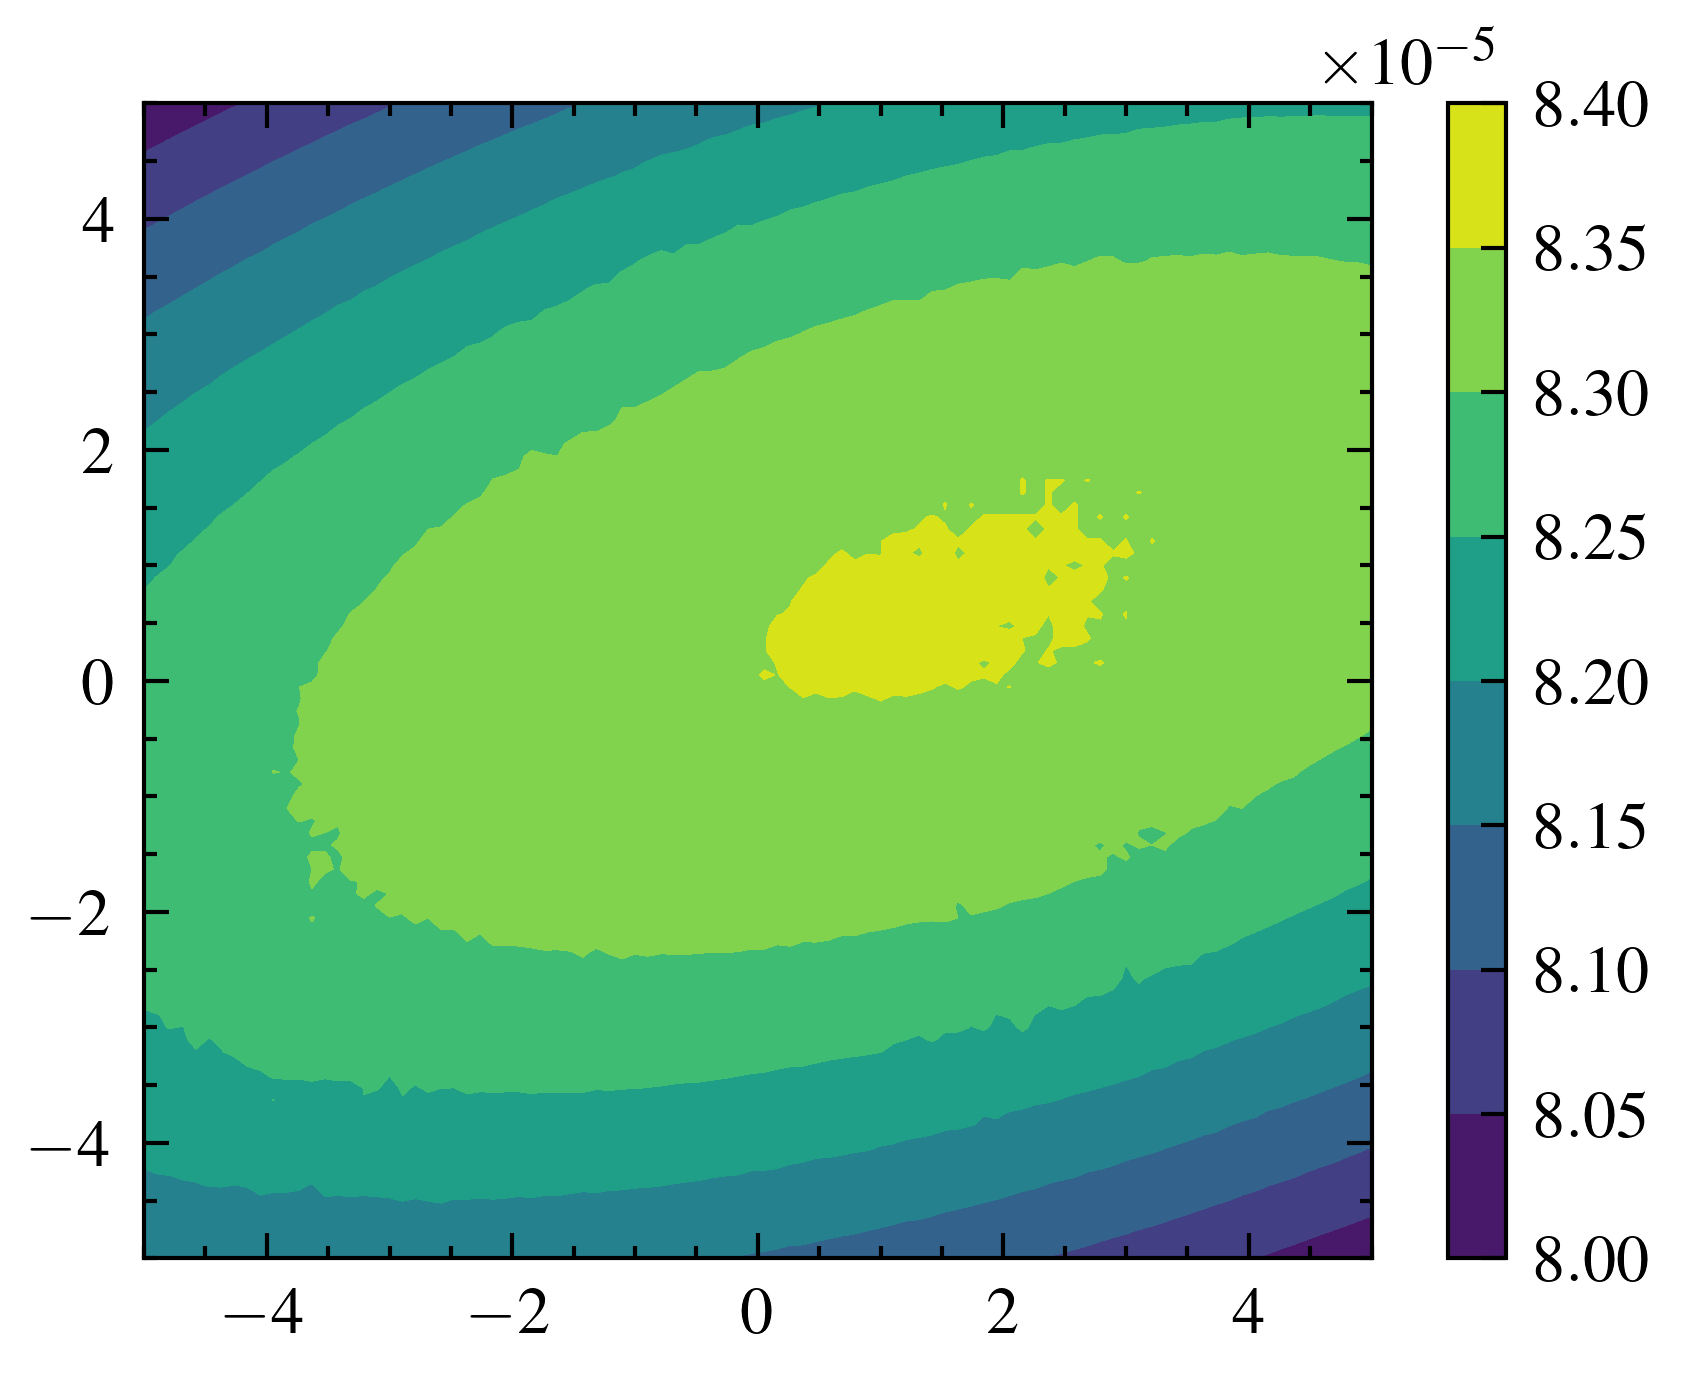

In [13]:
mt_sim, _ = field_exact(train['sources'], train['grid'], train['shape'], length=100)

if source_cfg["line"]:
    plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0])
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0], color='red', linestyle='--')
    # plt.plot(train['grid'][:, 0], train["field_grid"][0, ..., 0], color='red', linestyle='--')
    plt.plot(train['grid'][:, 0], mt_sim[0, ..., 0] / train["field_grid"][0, ..., 0], color='green', linestyle=':')
    # plt.yscale("log")
    # plt.xlim(5,15)
    plt.ylim(-2, 2)
    plt.legend(["Analytical", "MagTense", "Error"])
    print(np.nanmean(np.abs(mt_sim[0, :, 0] / train["field_grid"][0, :, 0])))

else:
    x_grid = np.array(train['grid'][:, 0].reshape((source_cfg["res"], source_cfg["res"])))
    y_grid = np.array(train['grid'][:, 1].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_x = np.array(mt_sim[0, ..., 0].reshape((source_cfg["res"], source_cfg["res"])))
    mt_f_grid_y = np.array(mt_sim[0, ..., 1].reshape((source_cfg["res"], source_cfg["res"])))
    t_f_x = train["field_grid"][0, ..., 0].reshape((source_cfg["res"], source_cfg["res"]))
    t_f_y = train["field_grid"][0, ..., 1].reshape((source_cfg["res"], source_cfg["res"]))
    # plt.contourf(x_grid, y_grid, np.clip(mt_f_grid_y, -5, 5))
    plt.contourf(x_grid, y_grid, np.clip(np.abs(mt_f_grid_y - t_f_y), 0, 0.1))
    plt.colorbar()
    print("Field(x):", np.nanmean(np.abs(mt_f_grid_x / t_f_x)))
    print("Field(y):", np.nanmean(np.abs(mt_f_grid_y / t_f_y)))